In [1]:
import timm 
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
import pandas as pd
import numpy as np
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm   # 新增进度条库
torch.manual_seed(2023)


In [2]:
f1 = []
from sklearn.metrics import f1_score

In [3]:
def build_model(num_classes = 11):
    return timm.create_model("mobilenetv3_large_100",pretrained=True,num_classes=num_classes)

def mixup_data(x, y, alpha=1.0):
    '''返回混合后的输入、原始标签a、打乱标签b、混合系数lam'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    '''计算 MixUp 损失'''
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [4]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用 tqdm 包装 dataloader，设置描述信息
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        images, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.205)
        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        running_loss += batch_loss * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_a = (preds == labels_a).sum().item()   ##新增一些数据增强
        correct_b = (preds == labels_b).sum().item()
        batch_correct = lam * correct_a + (1 - lam) * correct_b
        correct += batch_correct
        total += images.size(0)
     
        #total += labels.size(0)
        #correct += (preds == labels).sum().item()
        
        # 更新进度条显示当前 batch 的 loss 和 acc
        pbar.set_postfix({
            'Loss': f'{batch_loss:.4f}',
            'Acc': f'{correct/total:.4f}'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device, epoch, phase="Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_pred,all_labels = [],[]
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [{phase}]", leave=False)
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            all_pred.append(torch.argmax(outputs,dim = 1))
            all_labels.append(labels)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{correct/total:.4f}'
            })
    all_pred = torch.cat(all_pred).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    f1.append(f1_score(all_labels, all_pred, average='macro'))
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ---------------------- 5. 分层采样划分函数 ----------------------
def stratified_split(dataset, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    train_idx, val_idx, test_idx = [], [], []
    np.random.seed(random_seed)
    for cls in classes:
        cls_indices = np.where(targets == cls)[0]
        np.random.shuffle(cls_indices)
        n_cls = len(cls_indices)
        n_train = int(round(train_ratio * n_cls))
        n_val = int(round(val_ratio * n_cls))
        n_test = n_cls - n_train - n_val
        if n_test < 0:
            n_test = 0
            n_train = n_cls - n_val
        train_idx.extend(cls_indices[:n_train])
        val_idx.extend(cls_indices[n_train:n_train+n_val])
        test_idx.extend(cls_indices[n_train+n_val:])
    return train_idx, val_idx, test_idx

# ---------------------- 6. 支持不同 transform 的 Subset 包装类 ----------------------
from torch.utils.data import Dataset

class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform:
            x = self.transform(x)
        # 兜底：如果还不是 Tensor，强制转换
        if not isinstance(x, torch.Tensor):
            from torchvision.transforms import functional as F
            x = F.to_tensor(x)
        return x, y
# ---------------------- 7. 绘图函数 ----------------------
def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path="training_curves_mamba.png"):
    epochs = range(1, len(train_losses) + 1)
    epochs_for_f1=range(1, len(f1)+1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,3,3)
    plt.plot(epochs_for_f1,f1, 'b-', label='F1-score')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.title('F1-score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"训练曲线已保存至 {save_path}")

# ---------------------- 8. 主程序 ----------------------
def main(model = None):
    import sys
    from pathlib import Path
    for _base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        _src = _base / "src"
        if (_src / "raicom").is_dir() and str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
            break
    from raicom.paths import default_data_root
    data_root = default_data_root()  # 或 RAICOM_DATA_ROOT
    #这里可能要自己修改一下，按照你的文件夹

    batch_size = 32
    epochs = 50
    lr = 0.0004
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 数据增强
    # 定义不同的 transform
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_test = transforms.Compose([   # 测试集通常和验证集一样，不增强
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 1. 加载整个数据集（不应用 transform，后续用 SubsetWithTransform 分别加）
    full_dataset = datasets.ImageFolder(root=data_root, transform=None)  # 暂不加 transform
    num_classes = len(full_dataset.classes)
    print(f"发现 {num_classes} 个类别: {full_dataset.classes}")
    print(f"总样本数: {len(full_dataset)}")

    # 2. 分层采样划分索引 (训练:验证:测试 = 0.8:0.1:0.1)
    train_idx, val_idx, test_idx = stratified_split(
        full_dataset, 
        train_ratio=0.8, 
        val_ratio=0.1, 
        test_ratio=0.1, 
        random_seed=42
    )
    print(f"训练集大小: {len(train_idx)}, 验证集大小: {len(val_idx)}, 测试集大小: {len(test_idx)}")

    # 3. 用 SubsetWithTransform 分别包装，赋予不同的 transform
    train_dataset = SubsetWithTransform(full_dataset, train_idx, transform=transform_train)
    val_dataset   = SubsetWithTransform(full_dataset, val_idx,   transform=transform_val)
    test_dataset  = SubsetWithTransform(full_dataset, test_idx,  transform=transform_test)

    # 4. 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    # 后续模型构建、训练、验证、测试代码保持不变...
    # （你的 build_model, criterion, optimizer, 训练循环等）

    # 其余代码保持不变（模型构建、优化器、训练循环、绘图等）
    # ...
    if model == None:
        model = build_model(11).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=2.5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer = optimizer,
                                                     T_max = 50,
                                                     eta_min=1.75e-6)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_acc = 0.0
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss, val_acc = validate(model, val_loader, criterion, device, epoch, "Val")
        scheduler.step()
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 打印 epoch 汇总信息（进度条之外）
        print(f"\nEpoch {epoch:03d}/{epochs} | Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}\n")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "mobilenetv3_large_100.pth")
            print(f"  -> 保存最佳模型，验证准确率 {val_acc:.4f}\n")

    model.load_state_dict(torch.load("mobilenetv3_large_100.pth"))
    test_loss, test_acc = validate(model, test_loader, criterion, device, epoch=0, phase="Test")
    print(f"\n最终测试集准确率: {test_acc:.4f}")

    plot_curves(train_losses, val_losses, train_accs, val_accs, save_path="mobilenetv3_large_100.png")



使用设备: cuda
发现 11 个类别: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
总样本数: 6862
训练集大小: 5491, 验证集大小: 687, 测试集大小: 684



Epoch 001/50 | Train Loss 1.1216 | Train Acc 0.7084 | Val Loss 0.3710 | Val Acc 0.8836

  -> 保存最佳模型，验证准确率 0.8836




Epoch 002/50 | Train Loss 0.7653 | Train Acc 0.7921 | Val Loss 0.3586 | Val Acc 0.8777




Epoch 003/50 | Train Loss 0.5965 | Train Acc 0.8395 | Val Loss 0.3260 | Val Acc 0.9054

  -> 保存最佳模型，验证准确率 0.9054




Epoch 004/50 | Train Loss 0.5845 | Train Acc 0.8421 | Val Loss 0.2927 | Val Acc 0.9141

  -> 保存最佳模型，验证准确率 0.9141



...


Epoch 047/50 | Train Loss 0.3720 | Train Acc 0.8956 | Val Loss 0.2713 | Val Acc 0.9243




Epoch 048/50 | Train Loss 0.3552 | Train Acc 0.8892 | Val Loss 0.2679 | Val Acc 0.9229




Epoch 049/50 | Train Loss 0.3788 | Train Acc 0.8884 | Val Loss 0.2533 | Val Acc 0.9243




Epoch 050/50 | Train Loss 0.3816 | Train Acc 0.8872 | Val Loss 0.2543 | Val Acc 0.9229




最终测试集准确率: 0.9298


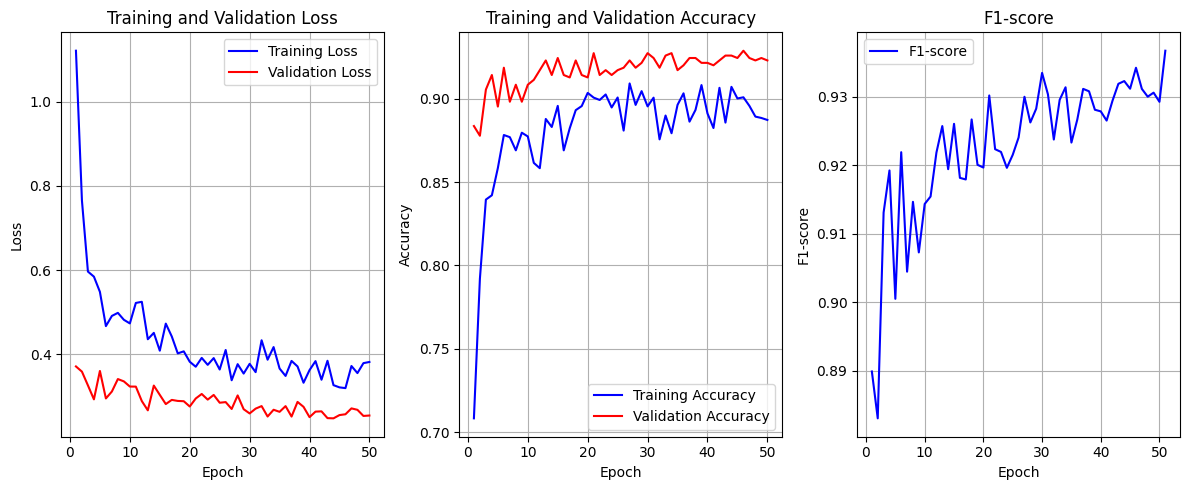

训练曲线已保存至 mobilenetv3_large_100.png


In [5]:
main()